<a href="https://colab.research.google.com/github/ganon-evans-capp/ds-20195-GE-final-project/blob/main/Data_and_the_State_Final_Project_GE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AirB-n-Barcelona

Microproject by Ganon Evans for Data and the State, Spring Quarter 2026

Over the last two decades, Barcelona has had waves of antitourist activism protesting increasing costs of living and housing shortages. Using data from the City of Barcelona and AirBnB, this project attempts to model the network of AirBnB owners across the city, including concentration by area and how the degree to which largescale owners exist.

# Background

For the 1992 Olympics, the industrial port city of Barcelona was transformed through urban development into a multicultural city on a scenic Mediterranean beach front [1]. In the decades after, Barcelona became a tourist hotspot. The city estimated that in 2023, it received 26 million tourists compared to its resident population of just 1.5 million people [2]. From 2000 and 2015, the number of cruise passengers stopping in Barcelona quintupled, with 57% of them not even spending the night in the city [1]. Despite the increase in visitors, the residential population near the city center declined by 11% between 2015 and 2019 - that accounts for about 100,000 people [Q].

The proliferation of tourism is not without its critics, who argue that the industry does not create high-paying jobs, inflates local prices, and constrains the housing market. Madrid and Barcelona, Spain's two largest urban centers, have costs of living that are 20% higher than elsewhere in the country; yet, the adjusted purchasing power from higher wages is only 21% higher, meaning that low-income communities with stagnant wages may be forced to move if tourism drives up prices [3]. Barcelona has been identified has one of the top cities in the EU with low housing stock, and between 2013 to 2016, rental income increased by 23% [4].

In 2017, the left-leaning Catalan collective Arran spraypainted tour buses, slashed the tires of rental bicycles, and occupied local beaches with banners reading "For the abolition of holiday rentals."[X]. The same year, Barcelona implemented a moratorium called the Special Tourist Accommodation Plan (PEAUT)   which suspended all new urban planning, licenses, and land management projects related to tourism; the plan was repealed in 2019 after protest by landlords and insufficient economic results [W]. In Summer 2025, water guns became symbols of affordable housing protestors, who targeted hostel residents and their workers [Y]. As of February 2026, Barcelona has a 15 euro nightly tourist task in place, and the parliament of Catalonia has approved a bill that would ban all holiday rentals by 2028 [Z].

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx

In [2]:
#quarterly AirBnB data for the last 12 months, recorded December 14th, 2025
airbnb_listings = pd.read_csv("data/listings.csv")
#a nice geojson of Barcelona's neighborhoods, also provided by AirBnB
barcelona_neighborhoods = gpd.read_file("data/neighbourhoods.geojson")

#Barcelona's property transactions data. Not geospatial, so we will have to match it to a the neighborhoods by the neighborhood name.
real_estate_df = pd.read_csv("data/2025_notaris_compravendes_trans_tip_us.csv")

BAR_EPSG = 25830 #Standard for mainland Spain


In [3]:
#Since the real_estate_df is in Catalan, I do some cleaning of the headers
real_estate_df = real_estate_df.rename(columns={"Nom_Barri": "neighbourhood", "Tipologia_Us_Desc": "property_use", "Nombre": "transaction_count"})

Part 1: Property Transactions by Neighbourhood

The transaction data lists how many transactions by property type in each neighborhood. Let's narrow the property transactions to properties labeled as residential units or for tourists. These three categories make up 53% of the rows and are contrasted with things like offices and commercial spaces.

In [4]:
real_estate_df = real_estate_df.loc[real_estate_df["property_use"].isin(["Residencial", "Turístic"])]

real_estate_df["property_use"] = real_estate_df["property_use"].replace({
    "Residencial": "Residential",
    "Turístic": "Tourist"
})

#NA values were listed as "..", so I turned everything into a number and dropped the empty rows
real_estate_df["transaction_count"] = pd.to_numeric(real_estate_df["transaction_count"], errors="coerce")
real_estate_df = real_estate_df.dropna(subset=["transaction_count"])

real_estate_joined_df = barcelona_neighborhoods.merge(real_estate_df, on="neighbourhood", how="right")

neighbourhood_rs_choro = real_estate_joined_df.dissolve(by="neighbourhood", aggfunc={"transaction_count": "sum"}).reset_index()

neighbourhood_rs_choro = neighbourhood_rs_choro.to_crs(BAR_EPSG)

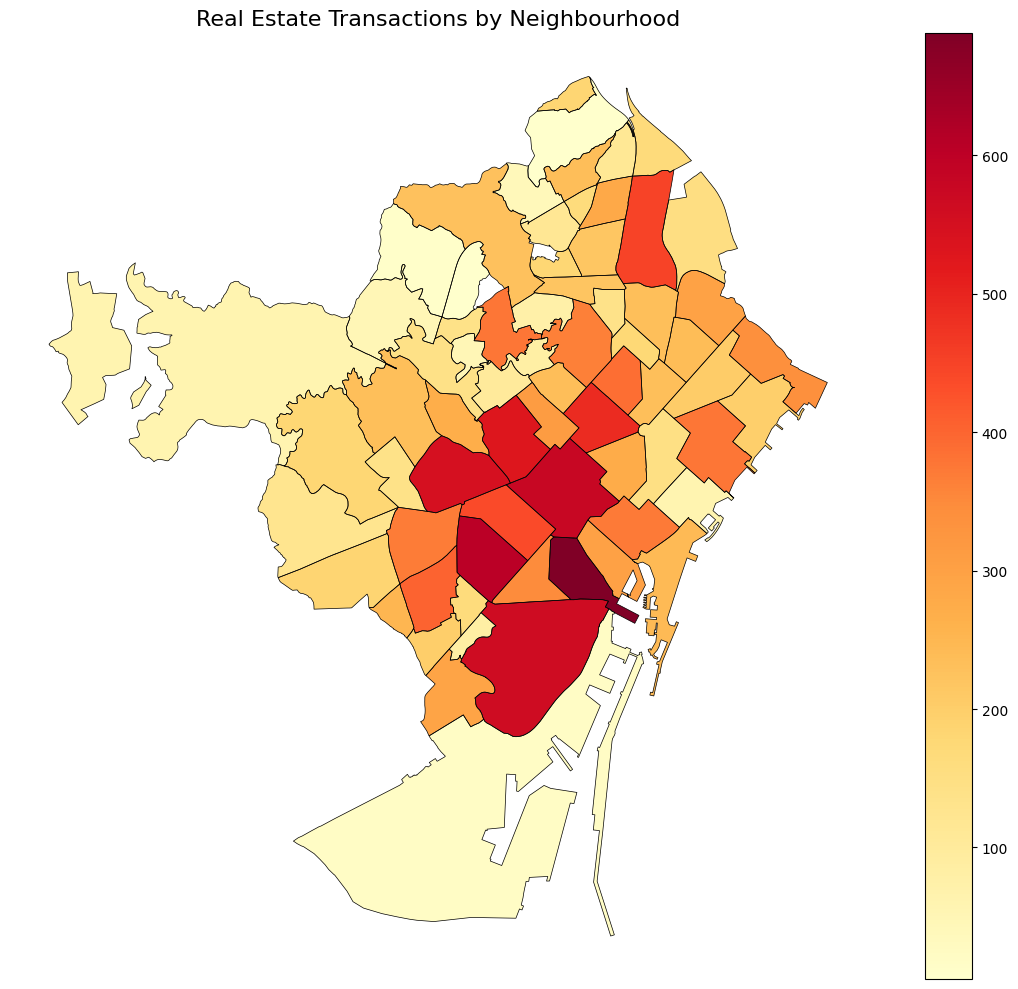

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
neighbourhood_rs_choro.plot(
    column="transaction_count",
    cmap="YlOrRd",
    legend=True,
    ax=ax,
)
neighbourhood_rs_choro.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.5
)
ax.set_title("Real Estate Transactions by Neighbourhood", fontsize=16)
ax.axis("off")
plt.tight_layout()
plt.show()

Now, we can plot the location of AirBnBs relative to the neighborhoods with the most real estate transactions.

In [6]:
airbnb_listings

def to_gdf(df):
    geometry = gpd.points_from_xy(df["longitude"], df["latitude"])  # x=lon, y=lat
    return gpd.GeoDataFrame(df, geometry=geometry, crs=4326).to_crs(BAR_EPSG)

airbnb_gdf = to_gdf(airbnb_listings)

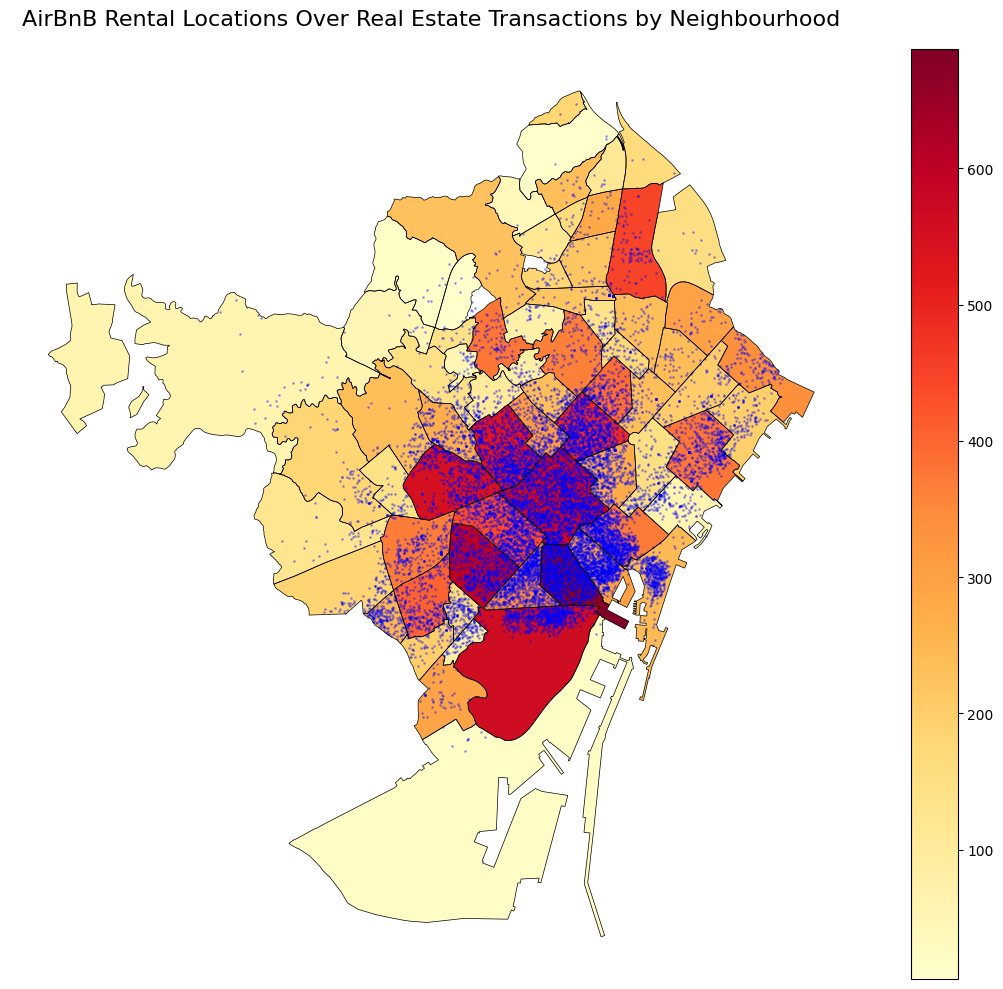

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
neighbourhood_rs_choro.plot(
    column="transaction_count",
    cmap="YlOrRd",
    legend=True,
    ax=ax,
)
neighbourhood_rs_choro.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.5
)
airbnb_gdf.plot(
    ax=ax,
    color="blue",
    markersize=1,
    alpha=0.3
)
ax.set_title("AirBnB Rental Locations Over Real Estate Transactions by Neighbourhood", fontsize=16)
ax.axis("off")
plt.tight_layout()
plt.show()

Well, there's a few problems here. For one, the AirBnB data is not an exact latitude and longitude of every residence out of privacy concerns. Similarly, its hard to tell in the city center if there's a significant difference between all of the points. 

Instead of plotting every AirBnB as an individual point, we can bin the listings into hexagonal cells and color each cell by how many listings fall inside it. This kernel-density-style view makes the concentration of rentals much easier to read. 

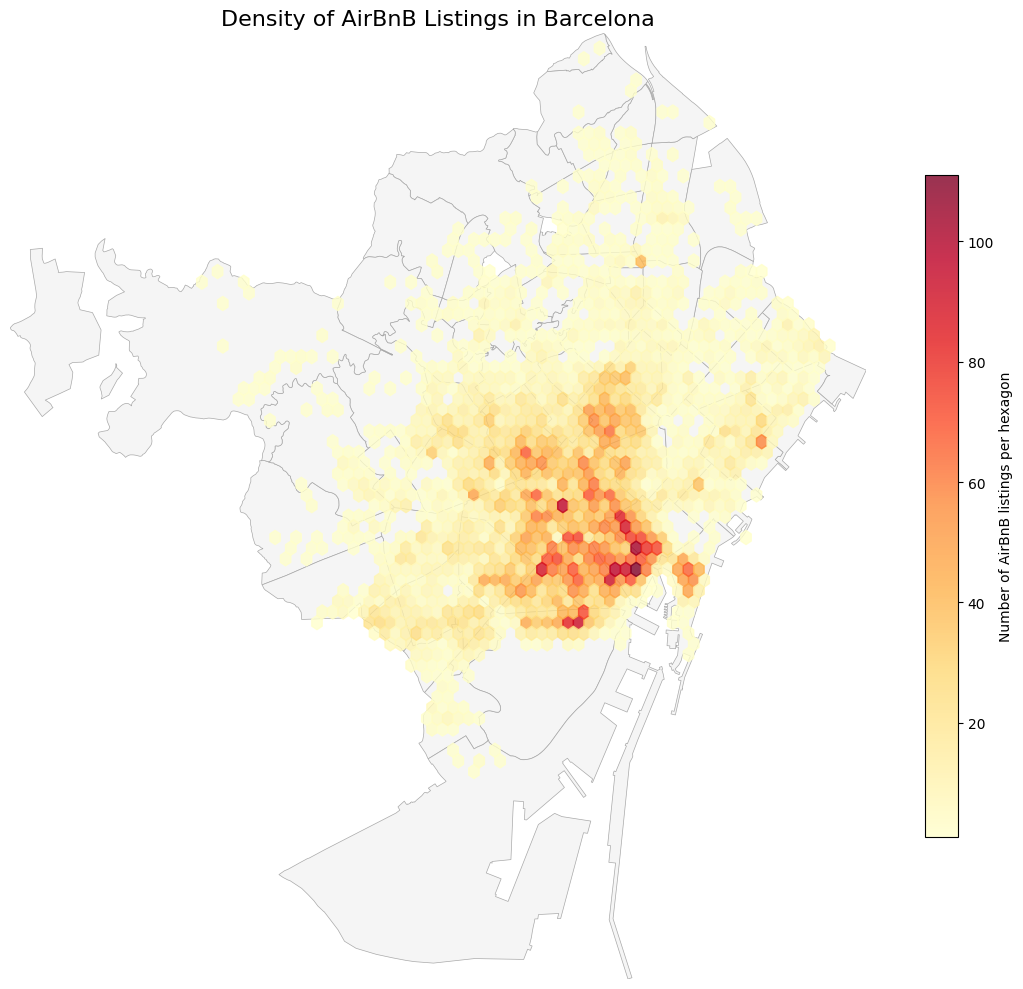

In [8]:
# Hexbin density map of AirBnB listings.
# No contextily needed — the neighbourhood polygons serve as the basemap.

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Light grey neighbourhood fill as the base layer.
neighbourhood_rs_choro.plot(
    ax=ax,
    color="whitesmoke",
    edgecolor="darkgrey",
    linewidth=0.5,
)

hb = ax.hexbin(
    airbnb_gdf.geometry.x,
    airbnb_gdf.geometry.y,
    gridsize=60,
    cmap="YlOrRd",
    mincnt=1,
    alpha=0.8,
)

cbar = fig.colorbar(hb, ax=ax, shrink=0.7)
cbar.set_label("Number of AirBnB listings per hexagon")

ax.set_xlim(*neighbourhood_rs_choro.total_bounds[[0, 2]])
ax.set_ylim(*neighbourhood_rs_choro.total_bounds[[1, 3]])

ax.set_title("Density of AirBnB Listings in Barcelona", fontsize=16)
ax.axis("off")
plt.tight_layout()
plt.show()

And what neighborhoods have the most listings?

In [9]:
airbnb_gdf

,id,name,host_id,host_profile_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,geometry
0,18674,Huge flat for 8 people close to Sagrada Familia,71615,1462508358342835057,Mireia,Eixample,la Sagrada Família,41.405560,2.17262,Entire home/apt,NaN,1,54,2025-11-19,0.35,24,115,9,Spain - National registration number<br />ESFC...,POINT (932421.906 4596708.26)
1,2031134,Sagrada Familia-auditorium. FREE WI-FI.,9100900,1462794940868112780,Miguel,Eixample,el Fort Pienc,41.400010,2.18416,Entire home/apt,NaN,2,453,2025-12-02,3.16,1,294,52,Barcelona - Regional registration number<br />...,POINT (933423.949 4596149.643)
2,4415694,DEEP PURPLE - RAMBLES,12385333,1462886557122269531,Yolanda,Sants-Montjuïc,el Poble Sec,41.372300,2.16441,Entire home/apt,NaN,3,182,2025-11-09,1.39,2,115,11,Barcelona - Regional registration number<br />...,POINT (931956.097 4592972.869)
3,4415780,"Double Room ""Barcelona""",4990426,1462670184572182763,Judith,Gràcia,la Vila de Gràcia,41.406670,2.16152,Private room,NaN,1,5,2016-10-19,0.04,1,0,0,NaN,POINT (931486.286 4596776.034)
4,5064035,Lovely 2 BD with terrace and wifi,1744516,1462577289140824079,Silvia & Luís,Gràcia,la Vila de Gràcia,41.399960,2.16339,Entire home/apt,NaN,3,128,2025-11-30,0.99,39,222,23,Spain - National registration number<br />ESHF...,POINT (931687.206 4596040.073)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18172,1574656863638461043,Habitación económica con wifi,731296157,1564548850394018347,Shirley Alisson,Eixample,la Dreta de l'Eixample,41.386120,2.16913,Private room,NaN,2,0,NaN,NaN,5,335,0,Barcelona - Regional registration number<br />...,POINT (932259.22 4594531.513)
18173,1574664158072287966,Habitación básica pero confortable,731296157,1564548850394018347,Shirley Alisson,Eixample,la Dreta de l'Eixample,41.388040,2.16863,Private room,NaN,2,0,NaN,NaN,5,352,0,Barcelona - Regional registration number<br />...,POINT (932204.64 4594742.274)
18174,1574674722789145942,Habitación práctica cerca del centro,731296157,1564548850394018347,Shirley Alisson,Eixample,la Dreta de l'Eixample,41.388090,2.16891,Private room,NaN,2,0,NaN,NaN,5,342,0,Barcelona - Regional registration number<br />...,POINT (932227.729 4594749.228)
18175,1574678224497628954,Cuarto privado para estancias cortas,731296157,1564548850394018347,Shirley Alisson,Eixample,la Dreta de l'Eixample,41.386200,2.16769,Private room,NaN,2,0,NaN,NaN,5,345,0,Barcelona - Regional registration number<br />...,POINT (932138.23 4594533.196)


In [10]:
top_10_df = (
    airbnb_gdf["neighbourhood"]
    .value_counts()
    .head(10)
    .rename_axis("Neighbourhood")
    .reset_index(name="AirBnB Listings")
)
top_10_df.index = range(1, len(top_10_df) + 1)  # rank starting at 1

styled = (
    top_10_df.style
    .background_gradient(cmap="YlOrRd", subset=["AirBnB Listings"])
    .format({"AirBnB Listings": "{:,}"})
    .set_caption("Top 10 Barcelona Neighbourhoods by AirBnB Listings")
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "14px"), ("font-weight", "bold"),
                   ("padding", "8px")]},
        {"selector": "th",
         "props": [("background-color", "#4a4a4a"), ("color", "white"),
                   ("text-align", "left"), ("padding", "6px 12px")]},
        {"selector": "td",
         "props": [("padding", "6px 12px")]},
    ])
)
styled

,Neighbourhood,AirBnB Listings
1,la Dreta de l'Eixample,"2,404"
2,el Raval,"1,330"
3,el Barri Gòtic,"1,167"
4,"Sant Pere, Santa Caterina i la Ribera","1,141"
5,la Vila de Gràcia,"1,056"
6,la Sagrada Família,"1,047"
7,l'Antiga Esquerra de l'Eixample,"1,006"
8,Sant Antoni,947
9,el Poble Sec,823
10,la Nova Esquerra de l'Eixample,766


Dreta de l'Eixample contains the physical city center of Barcelona at Plaça de Catalunya. El Raval is a historic nightlife district that borders La Rambla, a street famous for its pickpocketers who target oblivious tourists. Let's model these ten districts relative to the rest of the city.

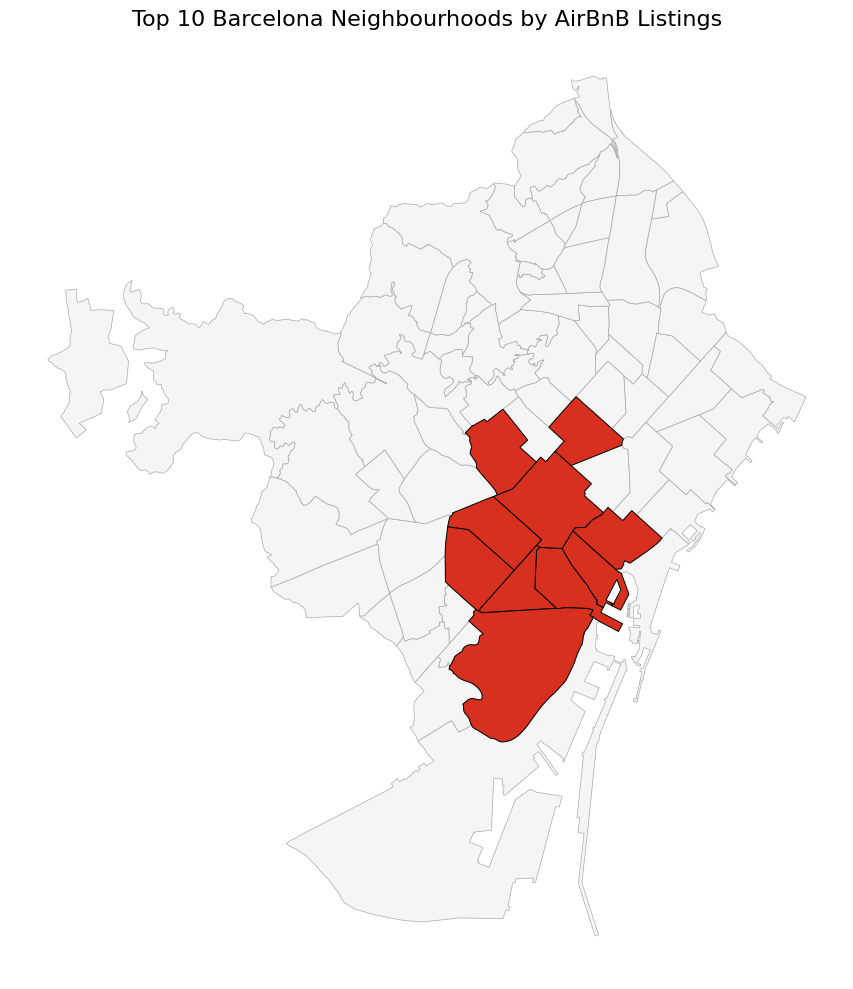

In [11]:
top_10_names = (
    airbnb_gdf["neighbourhood"]
    .value_counts()
    .head(10)
    .index
)

# Flag each neighbourhood polygon as top-10 or not
barcelona_map = barcelona_neighborhoods.to_crs(BAR_EPSG).copy()
barcelona_map["is_top_10"] = barcelona_map["neighbourhood"].isin(top_10_names)

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Non-highlighted neighbourhoods in light grey
barcelona_map[~barcelona_map["is_top_10"]].plot(
    ax=ax,
    color="whitesmoke",
    edgecolor="darkgrey",
    linewidth=0.5,
)

# Top 10 neighbourhoods highlighted
barcelona_map[barcelona_map["is_top_10"]].plot(
    ax=ax,
    color="#d7301f",
    edgecolor="black",
    linewidth=0.7,
)

ax.set_title("Top 10 Barcelona Neighbourhoods by AirBnB Listings",
             fontsize=16)
ax.axis("off")
plt.tight_layout()
plt.show()

The concentration of the AirBnBs in the city center is particularly sad in the context of stories of the cost-of-living driving local residents out.

# Part 2: Modeling Largescale AirBnB Owners in Barcelona

The AirBnB dataset tracks the hosts of each residence using a unique host ID. The 18,177 properties in the city are owned by a total of 5,776 unique hosts, which equates to each host owning 3 properties on average. However, the traits of these hosts range greatly.

In [12]:
print ("Total number of properties:", len(airbnb_gdf))

print ("Total number of unique hosts:", airbnb_gdf["host_id"].nunique())

Total number of properties: 18177
Total number of unique hosts: 5776


In [13]:
desc = airbnb_gdf["calculated_host_listings_count"].describe()

label_map = {
    "count": "Count",
    "mean": "Mean",
    "std": "Std. Deviation",
    "min": "Minimum",
    "25%": "25th Percentile",
    "50%": "Median",
    "75%": "75th Percentile",
    "max": "Maximum",
}
desc_df = (
    desc.rename(index=label_map)
    .rename_axis("Statistic")
    .reset_index(name="Value")
)

styled = (
    desc_df.style
    .hide(axis="index")
    .format({"Value": "{:,.2f}"})
    .set_caption("Host Listings Count — Summary Statistics")
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "14px"), ("font-weight", "bold"),
                   ("padding", "8px")]},
        {"selector": "th",
         "props": [("background-color", "#4a4a4a"), ("color", "white"),
                   ("text-align", "left"), ("padding", "6px 12px")]},
        {"selector": "td",
         "props": [("padding", "6px 12px")]},
    ])
)
styled

Statistic,Value
Count,"18,177.00"
Mean,68.49
Std. Deviation,129.20
Minimum,1.00
25th Percentile,2.00
Median,9.00
75th Percentile,52.00
Maximum,549.00


As clearly evidence by the large difference between the mean and median, a small number of AirBnB owners with a high amount of properties skew the ownership data to the right. 

Let's explore more about the hosts that are above the median of 9 properties when it comes to AirBnB ownership in the city. For the sake of convenience, we'll use the phrase "big landlords" for this group for the rest of the notebook.

In [19]:
big_landlords_gdf = airbnb_gdf.loc[airbnb_gdf["calculated_host_listings_count"] >= 9]

print ("The percentage of Barcelona AirBnB's owned by big landlords is ", len(big_landlords_gdf)/len(airbnb_gdf)*100, "%")

The percentage of Barcelona AirBnB's owned by big landlords is  50.993013148484344 %


Part 3: la Dreta de l'Eixample Networking

In the original dataset, la Dreta de l'Eixample had almost double the number of AirBnBs inside its borders than the next most property-heavy. What does a basic look at the property ownership look-like?

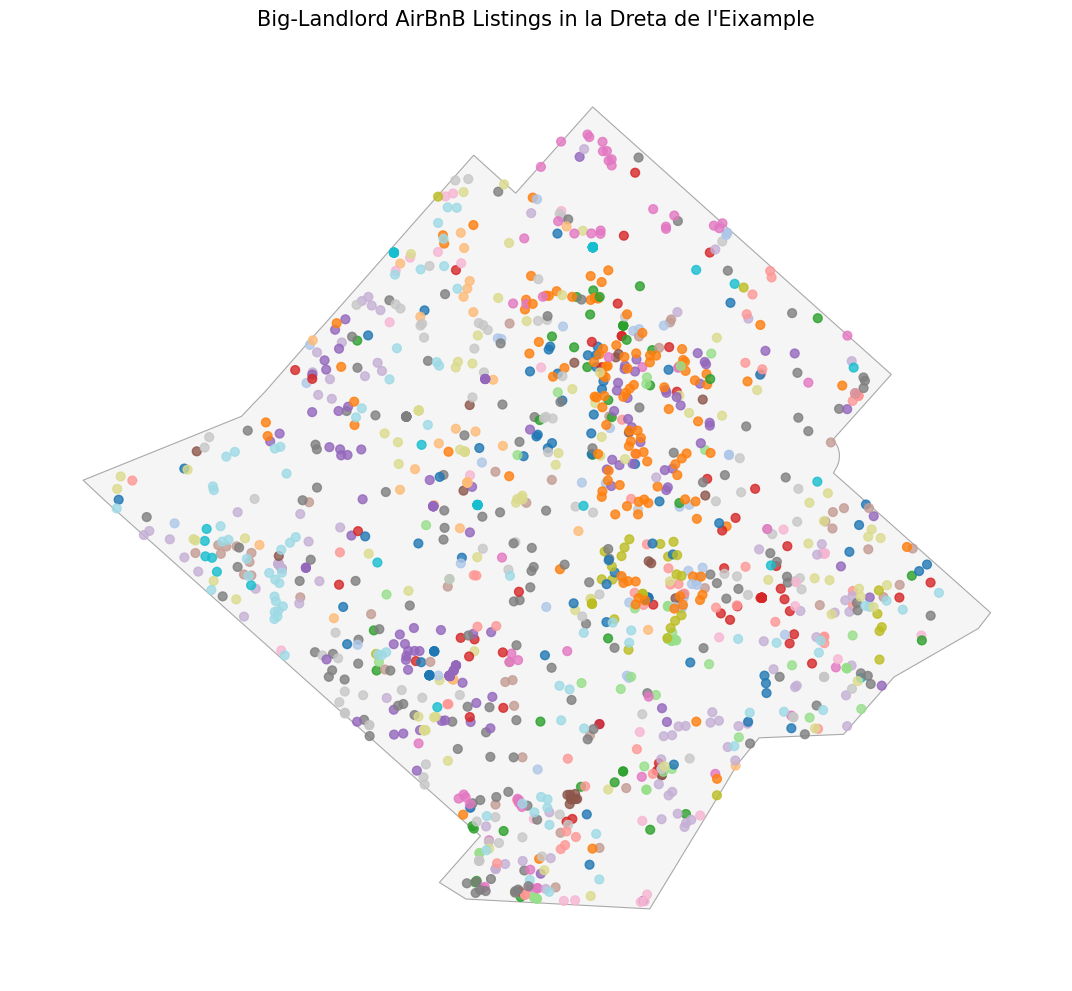

In [ ]:
dreta_gdf = big_landlords_gdf.loc[big_landlords_gdf["neighbourhood"] == "la Dreta de l'Eixample"]

# Join listings by host: one row per host, with a listing count
dreta_hosts = (
    dreta_gdf
    .dissolve(by="host_id", aggfunc={"host_name": "first"})
    .reset_index()
)
dreta_hosts["listings_in_dreta"] = (
    dreta_gdf.groupby("host_id").size().values
)

dreta_poly = barcelona_map.loc[barcelona_map["neighbourhood"] == "la Dreta de l'Eixample"]

fig, ax = plt.subplots(1, 1, figsize=(11, 10))

dreta_poly.plot(ax=ax, color="whitesmoke",
                edgecolor="darkgrey", linewidth=0.8)

# One marker per listing, colored by host
dreta_gdf.plot(
    ax=ax,
    column="host_id",
    categorical=True,
    cmap="tab20",
    markersize=40,
    alpha=0.8,
    legend=False,
)

minx, miny, maxx, maxy = dreta_poly.total_bounds
margin = 0.08 * max(maxx - minx, maxy - miny)
ax.set_xlim(minx - margin, maxx + margin)
ax.set_ylim(miny - margin, maxy + margin)

ax.set_title(f"Big-Landlord AirBnB Listings in la Dreta de l'Eixample",
             fontsize=15)
ax.axis("off")
plt.tight_layout()
plt.show()

Well, this looks like a nightmare to try and connect with a single graph: 138 hosts makes for a graph difficult to perceive. How about we limit it to just the super large hosts, who own 300 properties or more? And what if we also account for the location of some of the neighborhood's biggest sites, such as the 

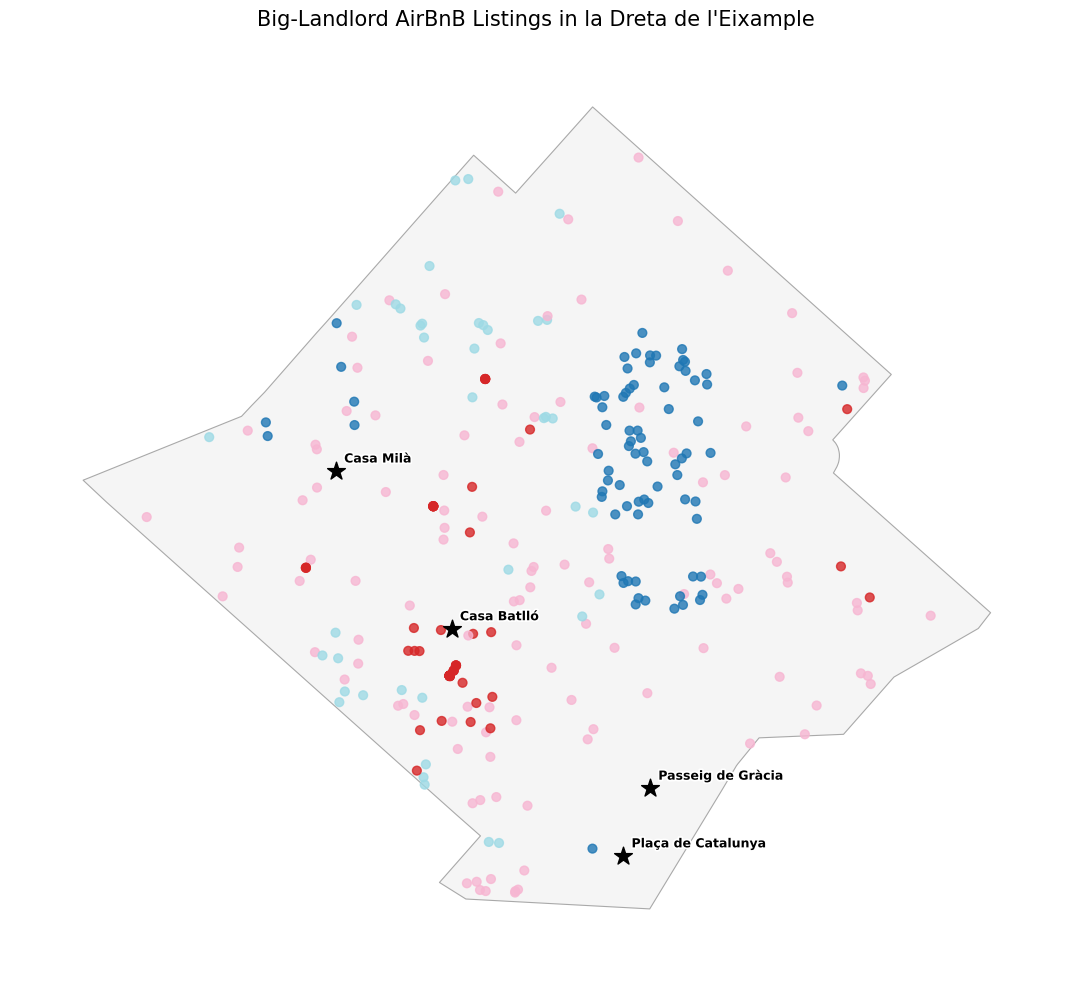

In [32]:
dreta_huge_gdf = big_landlords_gdf.loc[(big_landlords_gdf["neighbourhood"] == "la Dreta de l'Eixample") & (big_landlords_gdf["calculated_host_listings_count"] >= 300)]

# Join listings by host: one row per host, with a listing count
dreta_hosts = (
    dreta_huge_gdf
    .dissolve(by="host_id", aggfunc={"host_name": "first"})
    .reset_index()
)
dreta_hosts["huge_listings_in_dreta"] = (
    dreta_huge_gdf.groupby("host_id").size().values
)

fig, ax = plt.subplots(1, 1, figsize=(11, 10))

dreta_poly.plot(ax=ax, color="whitesmoke",
                edgecolor="darkgrey", linewidth=0.8)

# One marker per listing, colored by host
dreta_huge_gdf.plot(
    ax=ax,
    column="host_id",
    categorical=True,
    cmap="tab20",
    markersize=40,
    alpha=0.8,
    legend=False,
)

minx, miny, maxx, maxy = dreta_poly.total_bounds
margin = 0.08 * max(maxx - minx, maxy - miny)

# I used Google Maps to eyeball the coordinates
landmarks = pd.DataFrame({
    "name": ["Casa Batlló", "Casa Milà",
             "Plaça de Catalunya", "Passeig de Gràcia"],
    "latitude":  [41.391700, 41.395216, 41.386630, 41.388041],
    "longitude": [2.164918,  2.161902,  2.169399,  2.170273],
})

# Project to the same CRS as the map
landmarks_gdf = gpd.GeoDataFrame(
    landmarks,
    geometry=gpd.points_from_xy(landmarks["longitude"],
                                landmarks["latitude"]),
    crs=4326,
).to_crs(BAR_EPSG)

landmarks_gdf.plot(
    ax=ax,
    color="black",
    marker="*",
    markersize=180,
    zorder=5,
)
for _, row in landmarks_gdf.iterrows():
    ax.annotate(
        row["name"],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(6, 6),                 # small offset so text clears the star
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        color="black",
        zorder=6,
        path_effects=[
            __import__("matplotlib.patheffects", fromlist=["withStroke"])
            .withStroke(linewidth=2.5, foreground="white")
        ],
    )


ax.set_xlim(minx - margin, maxx + margin)
ax.set_ylim(miny - margin, maxy + margin)

ax.set_title(f"Big-Landlord AirBnB Listings in la Dreta de l'Eixample",
             fontsize=15)
ax.axis("off")
plt.tight_layout()
plt.show()

The large blue clump above away from some of the major tourist sites intrigued me, and made me think that it was potentially a hub for shopping and markets. Originally, I thought more AirBnBs would be directly on the city center, but that wasn't true.

# Part 3: Who is the biggest AirBnB owner in Barcelona? What does this network look like?

In [33]:
top_owner = airbnb_gdf.loc[airbnb_gdf["calculated_host_listings_count"] == airbnb_gdf["calculated_host_listings_count"].max()]

A host known as Ukio owns 524 different properties in the city of Barcelona. A cursory search finds their website, which is for short-term apartments advertised towards professionals, digital nomads, and students, among others. This is evidenced by the minimum number of nights for every properties, which is 31.

Conclusion: Ideas for Future Research

Who Owns Chicago comparison

If I had access to this data, how would I measure it?

Citations

[1] https://haroldgoodwin.info/RTPWP/012ManagingTourisminBarcelona.pdf

[2] https://www.greeneuropeanjournal.eu/wp-content/uploads/pdf/overtourism-barcelona-sparks-global-rethinking.pdf

[3] https://www.bde.es/f/webbde/SES/Secciones/Publicaciones/InformesBoletinesRevistas/ArticulosAnaliticos/21/T3/Files/be2103-art29e.pdf

[4] https://www.mdpi.com/2071-1050/10/6/2043

[Q] https://www.euronews.com/2019/07/23/barcelona-s-tourist-headache-as-residential-population-declines-11-since-2015

[W] Special Tourist Accommodation Plan (PEAUT)  https://storymaps.arcgis.com/stories/bda8850641684a40ae4199c449ee5a64

[X] https://pmc.ncbi.nlm.nih.gov/articles/PMC10445860/

[Y] https://www.ap.org/news-highlights/spotlights/2025/how-the-humble-water-gun-became-the-symbol-of-barcelonas-anti-tourism-movement/

[Z]https://www.reuters.com/business/barcelona-doubles-tourism-tax-one-highest-europe-fund-housing-2026-02-25/

https://insideairbnb.com/get-the-data/

https://opendata-ajuntament.barcelona.cat/data/en/dataset/notaris_compravendes_trans_tip_us

https://opendata-ajuntament.barcelona.cat/data/en/dataset/intensitat-activitat-turistica/resource/71499c6a-9947-4e06-88b7-0e26c39d12fe